# Predicting Ocean Current Speed Using Linear Regression

## Project Goal

The goal of this project is to investigate how accurately ocean current speed can be predicted from oceanographic variables using multivariable linear regression trained with gradient descent.

The input features are:
- Depth
- Hour of the day
- Month
- Temperature
- Salinity

The target variable is:
- Current Speed (m/s)

## Import Libraries

In [1]:
import copy, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading Dataset 
| **Variable** | **Description**                                                                     | **Dimensions**             |
| ------------ | ----------------------------------------------------------------------------------- | -------------------------- |
| **temp**     | Seawater temperature field                                                          | `(depth, longitude, time)` |
| **sal**      | Seawater salinity field                                                             | `(depth, longitude, time)` |
| **u**        | Eastward (zonal) current velocity component                                         | `(depth, longitude, time)` |
| **v**        | Northward (meridional) current velocity component                                   | `(depth, longitude, time)` |
| **depth**    | Depth of each grid cell. Varies with longitude because the ocean floor is not flat. | `(depth, longitude)`       |
| **time**     | Timestamp for each observation.                                                     | `(time)`                   |

Note: The temperature, salinity, and velocity fields are stored as three-dimensional arrays indexed by depth, longitude, and time. The eastward (u) and northward (v) velocity components are combined to compute the target variable, current speed, using:
$Current Speed = \sqrt(u^2+v^2)$

In [31]:
#Load cross section dataset from txt file
import sys
sys.path.append("..")  # notebooks/ is one level below root

from src.load_ocean_data import load_ocean_data
d = load_ocean_data("C:/Users/IMG/Documents/ocean-timeseries-ml/data/raw/xsec_south",
                    nz=39, nx=23, nt=26304, latitude=31.8,
                    start_time=pd.Timestamp("2016-01-01 13:00"),
                    time_resolution=1)

In [41]:
# verify dimensions
print("Depth dimension:", d["depth"].shape)
print("Time dimension (also number of data points):", d["time"].shape)
print("Temp dimension:", d["temp"].shape)
print("Salinity dimension:", d["sal"].shape)

Depth dimension: (39, 23)
Time dimension (also number of data points): (26304,)
Temp dimension: (39, 23, 26304)
Salinity dimension: (39, 23, 26304)


## Dataframe & Feature Table


| **Feature** | **Description**                                         | **Units** |
| ----------- | ------------------------------------------------------- | --------- |
| Longitude   | East-west position of the observation                   | °E        |
| Depth       | Depth below the sea surface at the observation location | m         |
| Hour        | Hour of the day extracted from the timestamp (0–23)     | -         |
| Month       | Month extracted from the timestamp (1–12)               | -         |
| Temperature | Seawater temperature                                    | °C        |
| Salinity    | Seawater salinity                                       | PSU       |
| **Target**  | **Current Speed**                                       | **m/s**   |

Number of samples (m)= 26302  
Number of features (n) = 6  
Target variable = current speed  


In [32]:
nz, nx, nt = d["temp"].shape

df = pd.DataFrame({
    "temp": d["temp"].ravel(),
    "salinity": d["sal"].ravel(),
    "u": d["u"].ravel(),
    "v": d["v"].ravel(),
    "speed": np.hypot(d["u"], d["v"]).ravel(),

    "depth": np.repeat(d["depth"].ravel(), nt),
    "hour": np.tile(d["time"].hour.values, nz * nx),
    "month": np.tile(d["time"].month.values, nz * nx),
})

## Visualizing Data

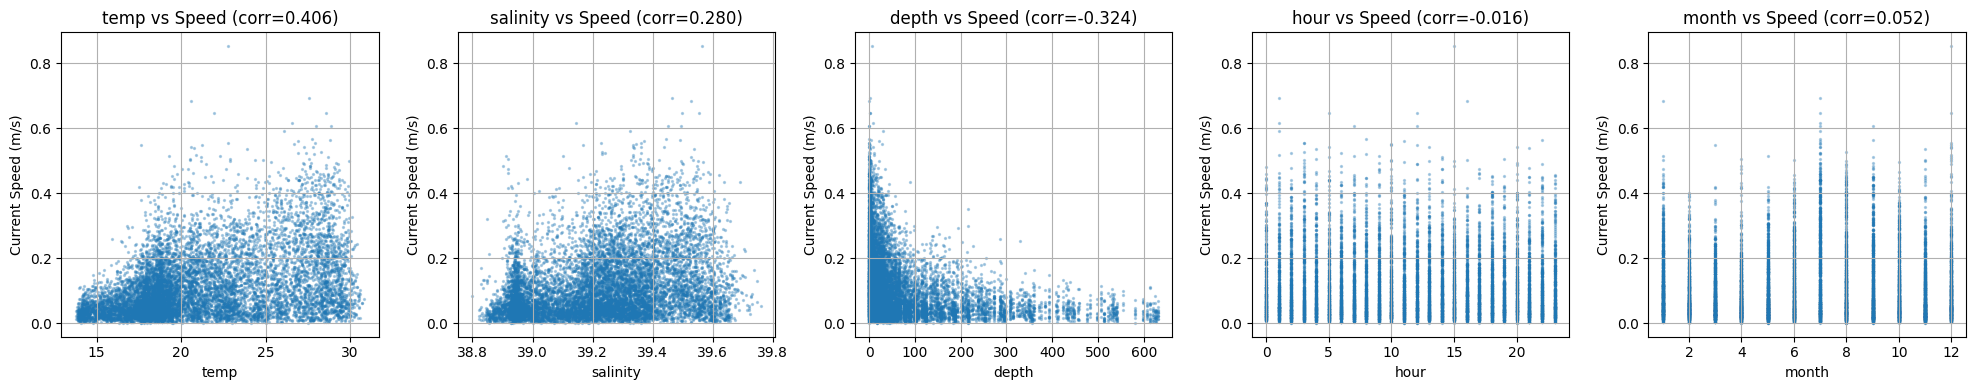

In [45]:
sample = df.sample(10000, random_state=0)

features = ["temp", "salinity", "depth", "hour", "month"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes = axes.ravel()

for i, col in enumerate(features):
    corr = df[col].corr(df["speed"])
    axes[i].scatter(sample[col], sample["speed"], s=2, alpha=0.3)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Current Speed (m/s)")
    axes[i].set_title(f"{col} vs Speed")
    axes[i].grid(True)
    axes[i].set_title(f"{col} vs Speed (corr={corr:.3f})")

plt.tight_layout()
plt.show()

## Data Preprocessing

The dataset is split into input features (X) and target variable (y).
X contains the oceanographic and temporal predictors (features matrix), while y represents current speed, which the model aims to predict.

In [33]:
X = df[["temp", "salinity", "depth", "hour", "month"]].values
y = df["speed"].values

The data is split into training (70%) and testing (30%) sets.
The model is trained on the training set and evaluated on the test set to ensure it generalizes well.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

### Feature Normalization

The input features have different units and numerical ranges (e.g., depth in meters, temperature in °C, and salinity in PSU). Since gradient descent is sensitive to the scale of the features, the input variables are standardized before training the model.

This project uses **Z-score standardization (standard scaling)**, which transforms each feature according to:

$$
z = \frac{x - \mu}{\sigma}
$$

where:

- $x$ is the original feature value,
- $\mu$ is the mean of the feature computed from the **training set**,
- $\sigma$ is the standard deviation of the feature computed from the **training set**.

After standardization, each feature has approximately:

- Mean = 0
- Standard deviation = 1

The scaler is fit only on the training data. The same mean and standard deviation are then used to transform the test data.

In [7]:
# normalize -> feature scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Peak to Peak range by column in Raw        X:{np.ptp(X_train,axis=0)}")   
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X_train_scaled,axis=0)}")

Peak to Peak range by column in Raw        X:[ 17.232    1.049  630.6576  23.      11.    ]
Peak to Peak range by column in Normalized X:[4.00941865 5.00142658 5.2803558  3.32282534 3.18923996]


In [11]:
#save normalized train and test data to file for quick use in coming sections
np.savez("../data/processed/current_speed_preprocessed_dataset.npz",
         X_train_scaled=X_train_scaled,
         X_test_scaled=X_test_scaled,
         y_train=y_train,
         y_test=y_test)

## Linear Regression Model Implementation Using My Own Functions

In [2]:
#import preprocessed dataset (optional, saves time if preprocessing already occured)
import numpy as np
import os

file_path = "../data/processed/current_speed_preprocessed_dataset.npz"

if os.path.exists(file_path):
    data = np.load(file_path)

    X_train_scaled = data["X_train_scaled"]
    X_test_scaled = data["X_test_scaled"]
    y_train = data["y_train"]
    y_test = data["y_test"]

    print("Data loaded successfully.")
else:
    print("File not found. Please run preprocessing first.")

Data loaded successfully.




Linear regression models the relationship between a set of input features and a continuous target variable by fitting a linear equation to the data.

For a dataset with $n$ features, the model is represented as

$$
f_{\mathbf{w},b}(\mathbf{x})=\mathbf{w}^T\mathbf{x}+b
$$

or equivalently,

$$
f_{\mathbf{w},b}(\mathbf{x}) =
w_1x_1+w_2x_2+\cdots+w_nx_n+b
$$

where:

- $\mathbf{x}=[x_1,x_2,\ldots,x_n]^T$ is the feature vector,
- $\mathbf{w}=[w_1,w_2,\ldots,w_n]^T$ is the vector of model coefficients (weights),
- $b$ is the intercept (bias) term.

---

The goal of training is to find the optimal values of $\mathbf{w}$ and $b$ that best fit the training data.

To evaluate how well a particular choice of parameters performs, a **cost function** is used. The cost function measures the difference between the model's predictions and the true target values.

The objective of training is therefore to find the values of $\mathbf{w}$ and $b$ that minimize the cost function.

---

One common optimization method for minimizing the cost function is **gradient descent**.

Gradient descent begins with an initial estimate of the model parameters and iteratively updates them in the direction that most rapidly decreases the cost. With each iteration, the parameters move closer to the values that minimize the prediction error.



In [4]:
def compute_cost(X, y, w, b):
    """
    Computes the cost function for linear regression.

    Args:
        X (ndarray): Shape (m,n) Data, m examples with n features
        y (ndarray): Shape (m,)  Label (target values)
        w (ndarray): Shape (n,)  Model weights
        b (scalar):  Model bias

    Returns
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in X and y
    """
    m = X.shape[0]
    f_wb = X @ w + b                       #(m,n)@(n,) + scalar = (m,)
    cost = np.sum((f_wb - y) ** 2) / (2 * m)
    return cost

In [5]:
def compute_gradient(X, y, w, b):
    """
    Computes the gradient for linear regression
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters
      b (scalar)       : model parameter

    Returns:
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w.
      dj_db (scalar):       The gradient of the cost w.r.t. the parameter b.
    """
    m = X.shape[0]
    err = (X @ w + b) - y          #(m,)
    dj_dw = (X.T @ err) / m         #(n,m)@(m,) = (n,)
    dj_db = np.sum(err) / m

    return dj_db, dj_dw

In [18]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn w and b. Updates w and b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X (ndarray (m,n))   : Data, m examples with n features
      y (ndarray (m,))    : target values
      w_in (ndarray (n,)) : initial model parameters  
      b_in (scalar)       : initial model parameter
      cost_function       : function to compute cost
      gradient_function   : function to compute the gradient
      alpha (float)       : Learning rate
      num_iters (int)     : number of iterations to run gradient descent
      
    Returns:
      w (ndarray (n,)) : Updated values of parameters 
      b (scalar)       : Updated value of parameter 
      """
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db,dj_dw = gradient_function(X, y, w, b)   ##None

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               ##None
        b = b - alpha * dj_db               ##None
      
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(X, y, w, b))

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
          print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2e}   ")
        
    return w, b, J_history #return final w,b and J history for graphing

In [13]:
# initialize parameters
initial_w = [0, 0, 0, 0, 0]
initial_b = 0.
# some gradient descent settings
iterations = 10
alpha = 1
# run gradient descent 
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")

Iteration    0: Cost     0.01   
Iteration    1: Cost     0.01   
Iteration    2: Cost     0.01   
Iteration    3: Cost     0.01   
Iteration    4: Cost     0.02   
Iteration    5: Cost     0.04   
Iteration    6: Cost     0.07   
Iteration    7: Cost     0.14   
Iteration    8: Cost     0.27   
Iteration    9: Cost     0.52   
b,w found by gradient descent: 0.11,[-0.34472148 -0.37011091  0.31599392 -0.00310255 -0.21775288] 


Here learning rate is clearly too large as the cost is increasing with iterations! Let's try again with alpha=0.1

In [19]:
iterations = 100
alpha = 0.1
# run gradient descent 
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")

Iteration    0: Cost 9.95e-03   
Iteration   10: Cost 4.82e-03   
Iteration   20: Cost 4.21e-03   
Iteration   30: Cost 4.12e-03   
Iteration   40: Cost 4.11e-03   
Iteration   50: Cost 4.10e-03   
Iteration   60: Cost 4.10e-03   
Iteration   70: Cost 4.09e-03   
Iteration   80: Cost 4.09e-03   
Iteration   90: Cost 4.09e-03   
b,w found by gradient descent: 0.11,[ 0.03839972  0.00162805 -0.00783177 -0.0017121  -0.01062737] 


This result is much better! Let's see if we can get any better by increasing alpha until right before the cost diverges and see if we can decrease the # of iterations with a faster learning rate.

In [29]:
iterations = 50
alpha = 0.8
# run gradient descent 
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")

Iteration    0: Cost 5.01e-03   
Iteration    5: Cost 4.33e-03   
Iteration   10: Cost 4.19e-03   
Iteration   15: Cost 4.13e-03   
Iteration   20: Cost 4.11e-03   
Iteration   25: Cost 4.10e-03   
Iteration   30: Cost 4.09e-03   
Iteration   35: Cost 4.09e-03   
Iteration   40: Cost 4.09e-03   
Iteration   45: Cost 4.09e-03   
b,w found by gradient descent: 0.11,[ 0.03986054  0.00112753 -0.00661275 -0.00172025 -0.01141455] 


This seems to be the lowest possible cost acheivable in this model. Let's take a look at the predictions visually.

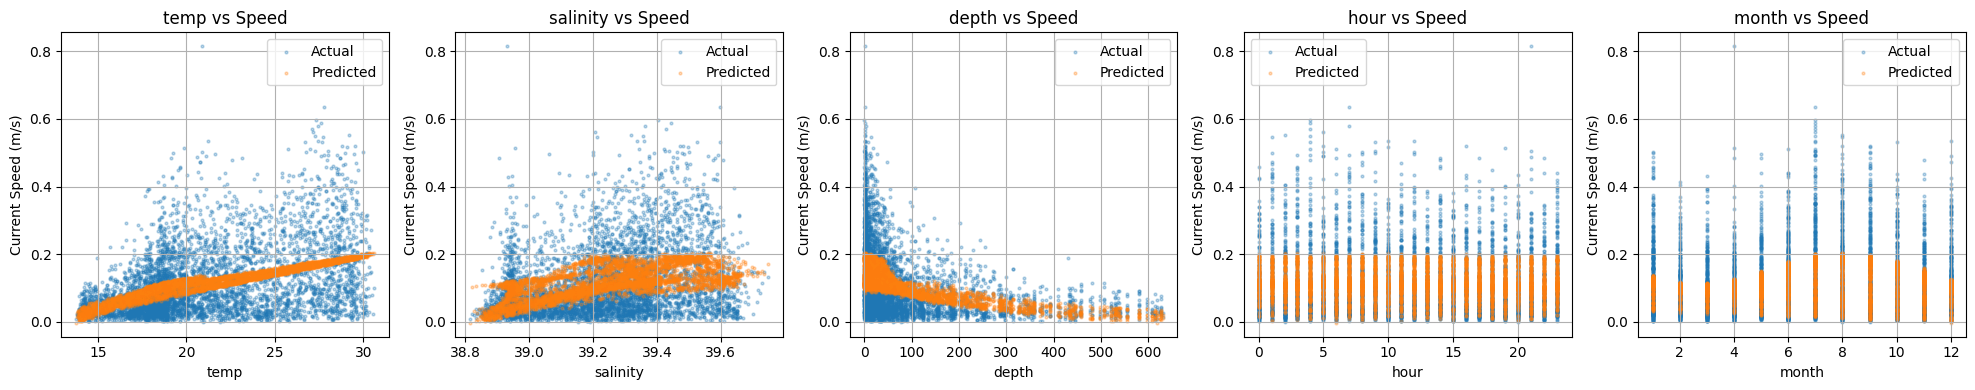

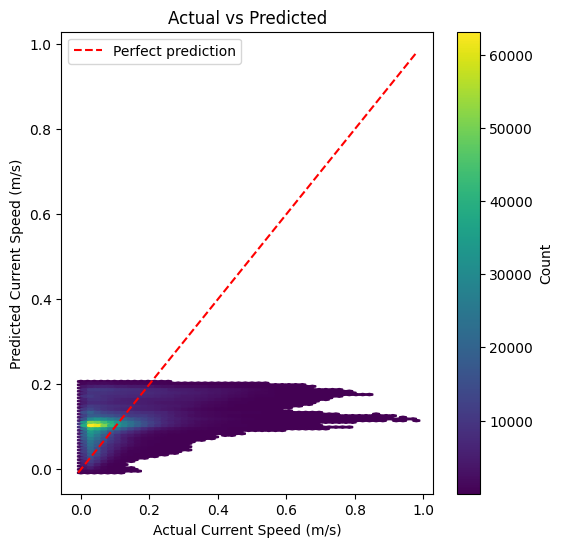

In [45]:
# Predictions using the fitted model (w_final, b_final) on scaled test features
y_pred = X_test_scaled @ w_final + b_final

# Downsample for fast plotting on large datasets
n_plot = 5000
idx = np.random.choice(len(y_test), size=min(n_plot, len(y_test)), replace=False)

# --- Per-feature: actual vs predicted, scattered against each raw feature value ---
features = ["temp", "salinity", "depth", "hour", "month"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes = axes.ravel()

for i, col in enumerate(features):
    axes[i].scatter(X_test[idx, i], y_test[idx], s=4, alpha=0.3, label="Actual", rasterized=True)
    axes[i].scatter(X_test[idx, i], y_pred[idx], s=4, alpha=0.3, label="Predicted", rasterized=True)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Current Speed (m/s)")
    axes[i].set_title(f"{col} vs Speed")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# Actual vs Predicted diagonal plot
plt.figure(figsize=(6, 6))
plt.hexbin(y_test, y_pred, gridsize=50, cmap="viridis", mincnt=1)
plt.colorbar(label="Count")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label="Perfect prediction")
plt.xlabel("Actual Current Speed (m/s)")
plt.ylabel("Predicted Current Speed (m/s)")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = X_test_scaled @ w_final + b_final

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4e}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")

MAE:  0.0680
MSE:  8.1802e-03
RMSE: 0.0904
R^2:  0.1827


## Linear Regression Model Implementation Using Scikit-Learn

In [47]:
#using scikit-learn

from sklearn.linear_model import SGDRegressor

sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_train_scaled, y_train)

print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

SGDRegressor()
number of iterations completed: 6, number of weight updates: 99097687.0


In [48]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")
y_pred = sgdr.predict(X_test_scaled)

model parameters:                   w: [ 0.04168274  0.00092813 -0.00598343 -0.00297446 -0.01130095], b:[0.11366103]


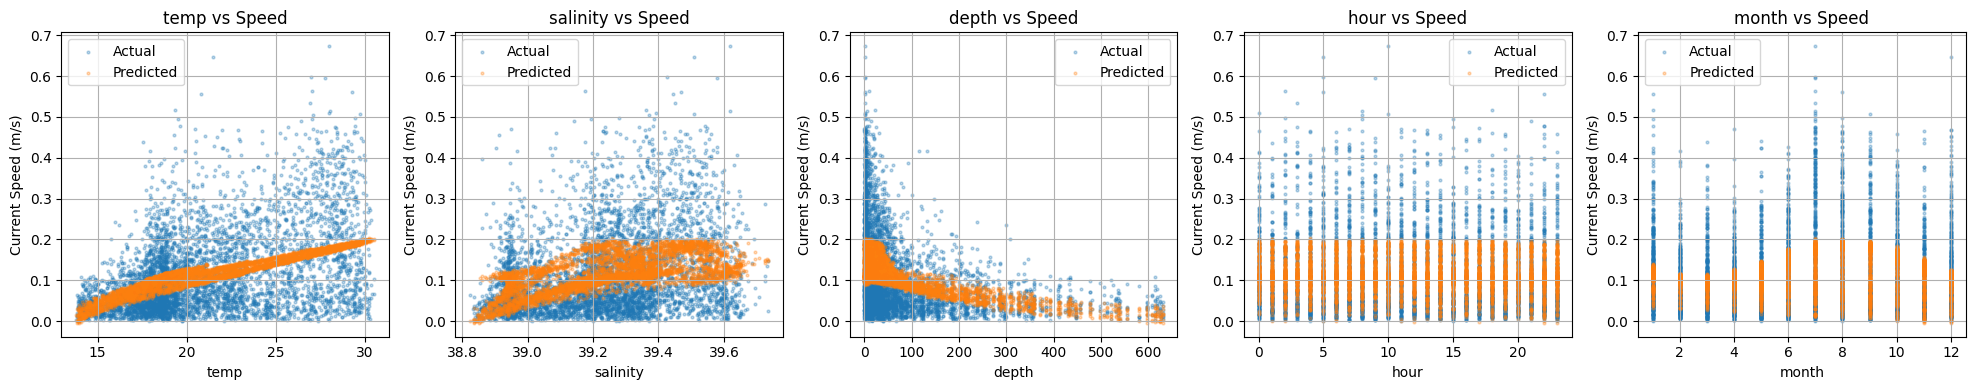

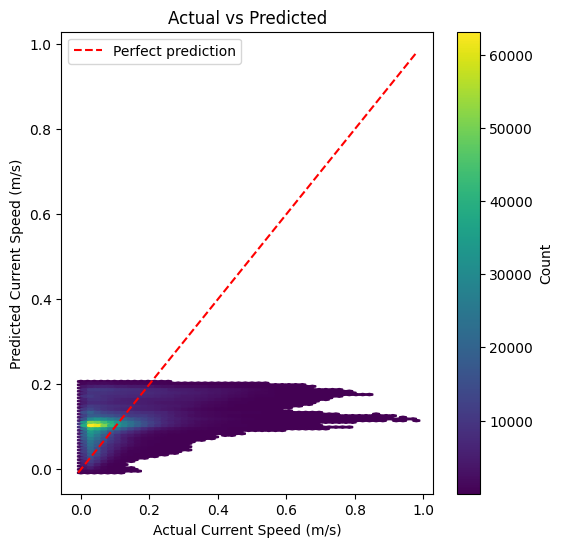

In [49]:
# Predictions using the fitted model (w_final, b_final) on scaled test features
y_pred = X_test_scaled @ w_final + b_final

# Downsample for fast plotting on large datasets
n_plot = 5000
idx = np.random.choice(len(y_test), size=min(n_plot, len(y_test)), replace=False)

# --- Per-feature: actual vs predicted, scattered against each raw feature value ---
features = ["temp", "salinity", "depth", "hour", "month"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes = axes.ravel()

for i, col in enumerate(features):
    axes[i].scatter(X_test[idx, i], y_test[idx], s=4, alpha=0.3, label="Actual", rasterized=True)
    axes[i].scatter(X_test[idx, i], y_pred[idx], s=4, alpha=0.3, label="Predicted", rasterized=True)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Current Speed (m/s)")
    axes[i].set_title(f"{col} vs Speed")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# Actual vs Predicted diagonal plot
plt.figure(figsize=(6, 6))
plt.hexbin(y_test, y_pred, gridsize=50, cmap="viridis", mincnt=1)
plt.colorbar(label="Count")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label="Perfect prediction")
plt.xlabel("Actual Current Speed (m/s)")
plt.ylabel("Predicted Current Speed (m/s)")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = X_test_scaled @ w_final + b_final

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4e}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")

MAE:  0.0680
MSE:  8.1802e-03
RMSE: 0.0904
R^2:  0.1827


In [51]:
for name, weight in zip(features, w_final):
    print(f"{name:10s}: w = {weight:.4e}")

temp      : w = 3.9861e-02
salinity  : w = 1.1275e-03
depth     : w = -6.6127e-03
hour      : w = -1.7202e-03
month     : w = -1.1415e-02


## Result Observations

- Both the custom implementation and the scikit-learn model produced similar results, confirming the gradient descent implementation is correct.
- Overall prediction accuracy is weak for current speeds above 0.2 m/s.
- R² = 0.1827, indicating the model explains only a small fraction of the variance in current speed — a poor fit overall.
- **Temperature, salinity, and depth** show a reasonably linear relationship with current speed, as expected, and the model captures this decently.
- **Hour and month** contribute little to the linear model's accuracy, since they are cyclical (periodic) rather than linear — a raw hour-of-day or month value doesn't correspond to a consistent linear effect on current speed.

### Next steps
- Try feature engineering (e.g., log transform for depth, sin/cos for hour and month) to see how much it improves accuracy.
